## 👤 About

**Created by:** Vishal Kumar  
**Program:** MSc Data Analytics & AI, EDHEC Business School  
**Contact:** 
- Email: vishal.kumar@edhec.com
- [LinkedIn](https://linkedin.com/in/vishalkr252)
- [GitHub](https://github.com/Vishal-VK-Kumar)


### Imports

In [1]:
import pandas as pd                    # For working with data tables
import numpy as np                     # For mathematical operations
import matplotlib.pyplot as plt        # For creating charts
import seaborn as sns                  # For prettier charts
from sklearn.cluster import KMeans     # For clustering customers
from sklearn.preprocessing import StandardScaler  # For normalizing data
import warnings
warnings.filterwarnings('ignore')      # To Hide warning messages

### Set style for charts

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Load Data

In [3]:
df = pd.read_csv('Data/data.csv', encoding='ISO-8859-1') # ISO-8859-1 tells python how to read Western European characters (£, €, ñ, ö, é, ç)

print("Dataset loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print("\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Total rows: 541,909
Total columns: 8

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


### Check data types and missing values


In [4]:
print("📊 DATASET INFORMATION:")
print("="*50)
print(df.info())

print("\n❌ MISSING VALUES:")
print("="*50)
print(df.isnull().sum())

print("\n📈 BASIC STATISTICS:")
print("="*50)
print(df.describe())

📊 DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

❌ MISSING VALUES:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

📈 BASIC STATISTICS:
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   

### Cleaning the Data

In [5]:
print("🧹 CLEANING DATA...")
print("="*50)

# Original size
original_size = len(df)

# Remove rows with missing CustomerID (can't segment without customer info)
df = df.dropna(subset=['CustomerID'])
print(f"Removed {original_size - len(df):,} rows with missing CustomerID")

# Remove cancelled orders (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
print(f"Dataset now has {len(df):,} rows")

# Remove negative quantities and prices (returns/errors)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"After removing negative values: {len(df):,} rows")

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\n✅ Data cleaning complete!")

🧹 CLEANING DATA...
Removed 135,080 rows with missing CustomerID
Dataset now has 397,924 rows
After removing negative values: 397,884 rows

✅ Data cleaning complete!


### Feature Engineering

In [6]:
# Create new columns we need for analysis

# Calculate total amount for each transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Set reference date (for calculating recency)
# We'll use 1 day after the most recent date in dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for recency calculation: {reference_date.date()}")

print("\n✅ New features created!")

Reference date for recency calculation: 2011-12-10

✅ New features created!


### RFM Analysis

In [7]:
# Calculate Recency, Frequency, Monetary for each customer

print("📊 CALCULATING RFM METRICS...")
print("="*50)

# Group by CustomerID and calculate:
# R = Recency (days since last purchase)
# F = Frequency (number of purchases)
# M = Monetary (total amount spent)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalAmount': 'sum'                                        # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Remove outliers (customers with extreme values)
# Keep customers within 99th percentile
for col in ['Recency', 'Frequency', 'Monetary']:
    upper_limit = rfm[col].quantile(0.99)
    rfm = rfm[rfm[col] <= upper_limit]

print(f"Total customers analyzed: {len(rfm):,}")
print("\nRFM Summary Statistics:")
print(rfm.describe().round(2))

📊 CALCULATING RFM METRICS...
Total customers analyzed: 4,212

RFM Summary Statistics:
       Recency  Frequency  Monetary
count  4212.00    4212.00   4212.00
mean     91.26       3.64   1308.93
std      96.74       3.84   1728.99
min       1.00       1.00      3.75
25%      18.00       1.00    306.91
50%      51.00       2.00    663.10
75%     139.00       4.00   1581.35
max     369.00      30.00  13027.45


### Visualize RFM Distributions

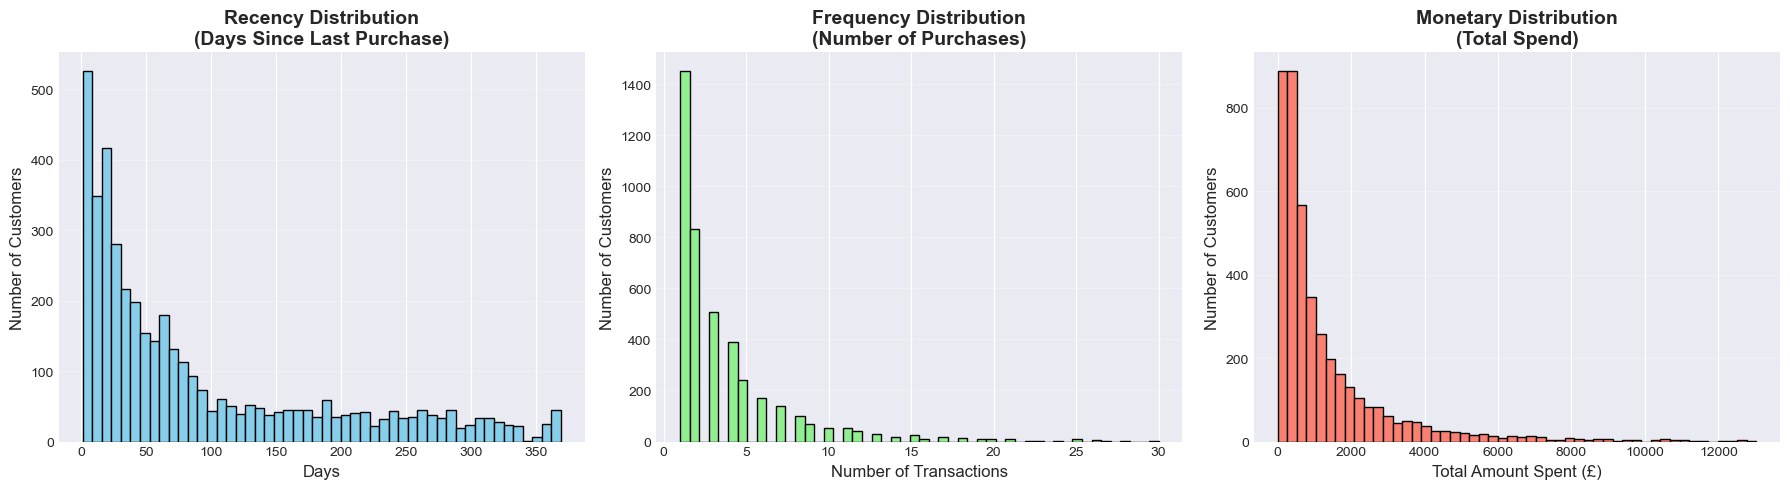

✅ Chart saved as rfm_distributions.png


In [8]:
# First to see how our data looks before clustering

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency distribution
axes[0].hist(rfm['Recency'], bins=50, color='skyblue', edgecolor='black') # bin divides the data into 'x' parts
axes[0].set_title('Recency Distribution\n(Days Since Last Purchase)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Frequency distribution
axes[1].hist(rfm['Frequency'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Frequency Distribution\n(Number of Purchases)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Transactions', fontsize=12)
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].grid(axis='y', alpha= 0.3)

# Monetary distribution
axes[2].hist(rfm['Monetary'], bins=50, color='salmon', edgecolor='black')
axes[2].set_title('Monetary Distribution\n(Total Spend)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Total Amount Spent (£)', fontsize=12)
axes[2].set_ylabel('Number of Customers', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as rfm_distributions.png")

### Normalize Data

In [9]:
# K-Means needs all variables on same scale

print("🔄 NORMALIZING DATA...")
print("="*50)

# Create a scaler
scaler = StandardScaler()

# Fit and transform the data
rfm_scaled = scaler.fit_transform(rfm)

print("Data normalized successfully!")
print("Mean of scaled data:", rfm_scaled.mean(axis=0).round(4))
print("Std of scaled data:", rfm_scaled.std(axis=0).round(4))

🔄 NORMALIZING DATA...
Data normalized successfully!
Mean of scaled data: [-0. -0.  0.]
Std of scaled data: [1. 1. 1.]


### Optimal number of clusters

🔍 FINDING OPTIMAL NUMBER OF CLUSTERS...
K=2: Inertia=7312.12
K=3: Inertia=4127.28
K=4: Inertia=2933.07
K=5: Inertia=2499.46
K=6: Inertia=2114.24
K=7: Inertia=1823.39
K=8: Inertia=1625.19
K=9: Inertia=1465.23
K=10: Inertia=1351.23


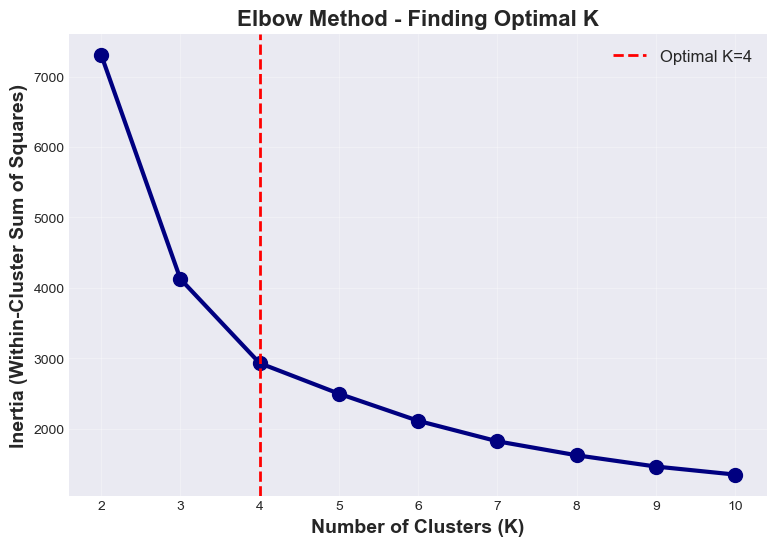


✅ Optimal number of clusters appears to be: 4
✅ Chart elbow_curve.png saved


In [10]:
# Use the Elbow Method

print("🔍 FINDING OPTIMAL NUMBER OF CLUSTERS...")
print("="*50)

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(9, 6))
plt.plot(K_range, inertias, marker='o', linewidth=3, markersize=10, color='navy')
plt.xlabel('Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=14, fontweight='bold')
plt.title('Elbow Method - Finding Optimal K', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

# Mark the elbow point (typically 4 or 5 for this dataset)
optimal_k = 4  
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
plt.legend(fontsize=12)

plt.savefig('Figures/elbow_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Optimal number of clusters appears to be: {optimal_k}")
print('✅ Chart elbow_curve.png saved')

### Clustering

In [11]:
# Apply K-Means with optimal K

optimal_k = 4  # Based on elbow curve

print(f"🎯 CLUSTERING WITH K={optimal_k}...")
print("="*50)

# Create and fit the model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"Clustering complete!")
print(f"\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

🎯 CLUSTERING WITH K=4...
Clustering complete!

Customers per cluster:
Cluster
0     843
1     990
2     221
3    2158
Name: count, dtype: int64


### Analysis of Clusters

In [12]:
# Understand characteristics of each segment

print("📊 CLUSTER CHARACTERISTICS:")
print("="*50)

# Calculate average RFM values per cluster
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# Add customer count
cluster_summary['Customer_Count'] = rfm.groupby('Cluster').size()

# Add percentage
cluster_summary['Percentage'] = (cluster_summary['Customer_Count'] / len(rfm) * 100).round(1)

print(cluster_summary)

📊 CLUSTER CHARACTERISTICS:
         Recency  Frequency  Monetary  Customer_Count  Percentage
Cluster                                                          
0          30.96       6.81   2567.47             843        20.0
1         246.03       1.50    439.39             990        23.5
2          19.64      14.95   6815.18             221         5.2
3          51.14       2.22    652.31            2158        51.2


### 3D Visualization of Clusters

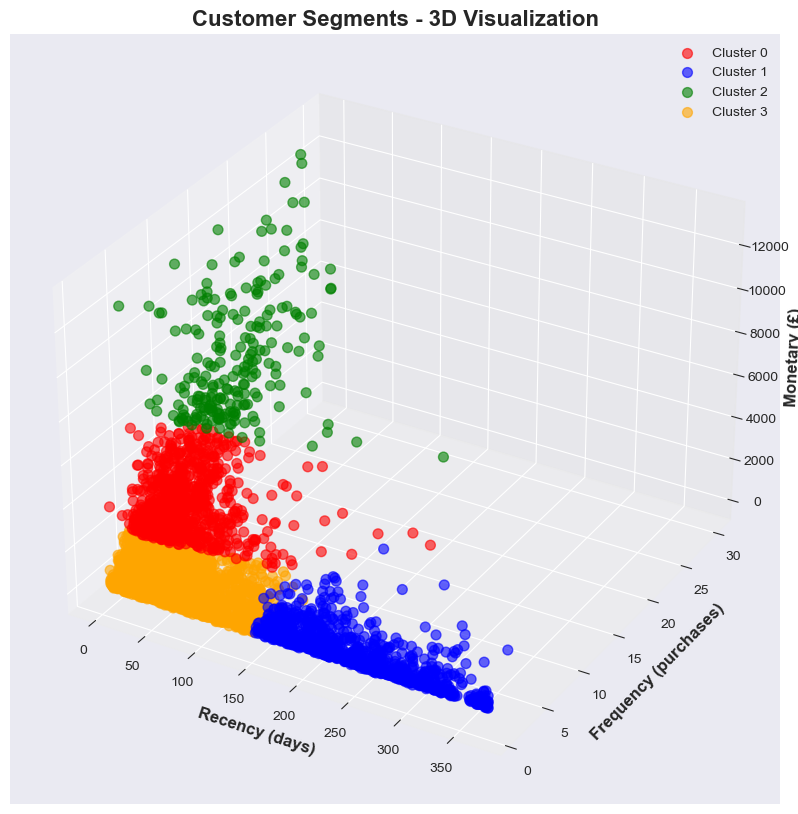

✅ 3D visualization saved!


In [13]:
# See the clusters in 3D space

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster with different color
colors = ['red', 'blue', 'green', 'orange', 'purple']

for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], 
               cluster_data['Frequency'], 
               cluster_data['Monetary'],
               c=colors[cluster],
               label=f'Cluster {cluster}',
               s=50,
               alpha=0.6)

ax.set_xlabel('Recency (days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (purchases)', fontsize=12, fontweight='bold')
ax.set_zlabel('Monetary (£)', fontsize=12, fontweight='bold')
ax.set_title('Customer Segments - 3D Visualization', fontsize=16, fontweight='bold')
ax.legend(fontsize=10)

plt.savefig('Figures/cluster_3d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 3D visualization saved!")

### Segments

In [14]:
# Names based on characteristics

segment_names = {
    2: 'Champions',           # Low recency, high frequency, high monetary
    0: 'Loyal Customers',     # Medium across all
    3: 'At Risk',            # High recency, medium frequency
    1: 'Lost Customers'       # Very high recency, low frequency
}


rfm['Segment_Name'] = rfm['Cluster'].map(segment_names)

print("📋 FINAL SEGMENTATION:")
print("="*50)
print(rfm.groupby('Segment_Name').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Customer_Count'}).round(2))

📋 FINAL SEGMENTATION:
                 Recency  Frequency  Monetary  Customer_Count
Segment_Name                                                 
At Risk            51.14       2.22    652.31            2158
Champions          19.64      14.95   6815.18             221
Lost Customers    246.03       1.50    439.39             990
Loyal Customers    30.96       6.81   2567.47             843


### Visualizations(Bar Graphs)

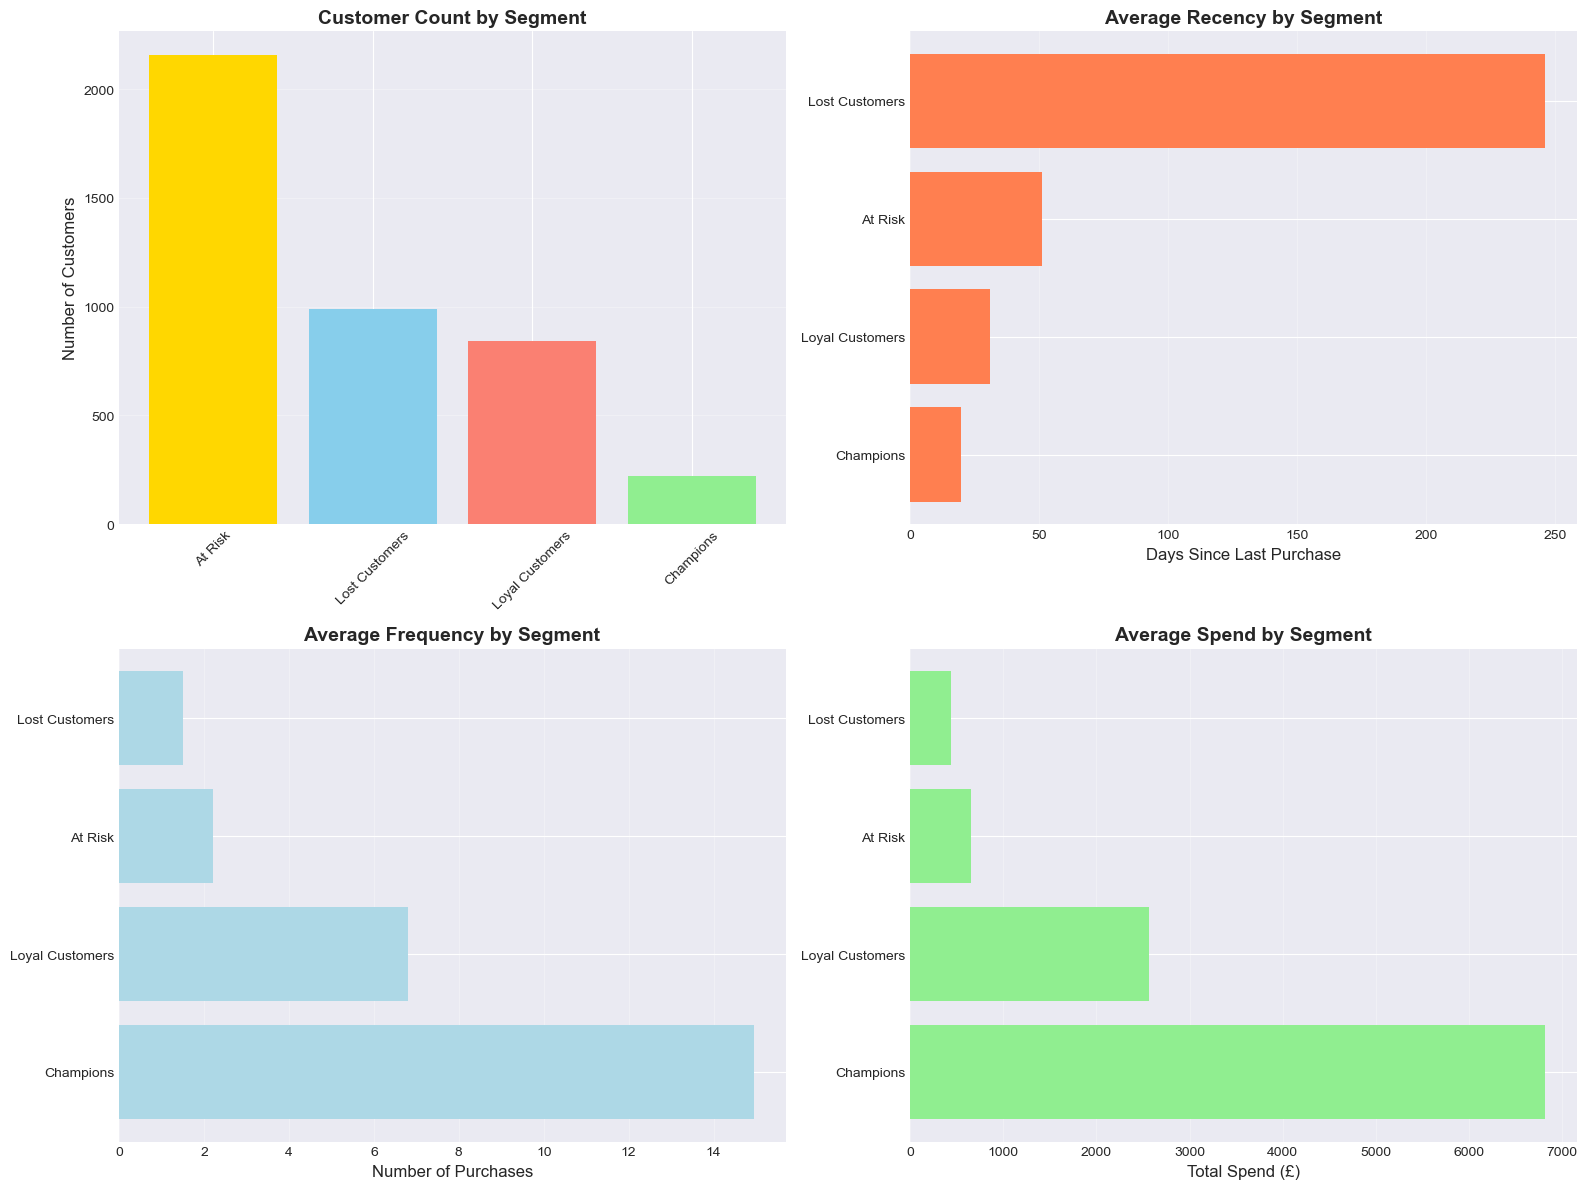

✅ Segment analysis chart saved!


In [15]:
# Show segment sizes and characteristics

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Customer count by segment
segment_counts = rfm['Segment_Name'].value_counts()
axes[0, 0].bar(segment_counts.index, segment_counts.values, color=['gold', 'skyblue', 'salmon', 'lightgreen'])
axes[0, 0].set_title('Customer Count by Segment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Customers', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Average Recency by segment
segment_recency = rfm.groupby('Segment_Name')['Recency'].mean().sort_values()
axes[0, 1].barh(segment_recency.index, segment_recency.values, color='coral')
axes[0, 1].set_title('Average Recency by Segment', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Days Since Last Purchase', fontsize=12)
axes[0, 1].grid(axis='x', alpha=0.3)

# Average Frequency by segment
segment_frequency = rfm.groupby('Segment_Name')['Frequency'].mean().sort_values(ascending=False)
axes[1, 0].barh(segment_frequency.index, segment_frequency.values, color='lightblue')
axes[1, 0].set_title('Average Frequency by Segment', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Purchases', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)

# Average Monetary by segment
segment_monetary = rfm.groupby('Segment_Name')['Monetary'].mean().sort_values(ascending=False)
axes[1, 1].barh(segment_monetary.index, segment_monetary.values, color='lightgreen')
axes[1, 1].set_title('Average Spend by Segment', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Total Spend (£)', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Figures/segment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Segment analysis chart saved!")

### Export Results

In [16]:
# Save the segmented customer data

# Save to CSV
rfm.to_csv('Data/customer_segments.csv', index=True)

print("✅ Results saved to data/customer_segments.csv")
print(f"\nTotal customers segmented: {len(rfm):,}")

✅ Results saved to data/customer_segments.csv

Total customers segmented: 4,212


### Business Recommendations

In [17]:
# Generate actionable insights

print("\n" + "="*70)
print("💼 BUSINESS RECOMMENDATIONS")
print("="*70)

for segment in segment_names.values():
    segment_data = rfm[rfm['Segment_Name'] == segment]
    count = len(segment_data)
    pct = (count / len(rfm) * 100)
    avg_monetary = segment_data['Monetary'].mean()
    
    print(f"\n📊 {segment.upper()}")
    print(f"   Size: {count:,} customers ({pct:.1f}%)")
    print(f"   Avg Spend: £{avg_monetary:,.2f}")
    print(f"   Avg Recency: {segment_data['Recency'].mean():.0f} days")
    print(f"   Avg Frequency: {segment_data['Frequency'].mean():.1f} purchases")
    
    # Recommendations based on segment
    if 'Champions' in segment or 'Loyal' in segment:
        print(f"   💡 Strategy: Reward loyalty, VIP treatment, early access to new products")
        print(f"   💰 Revenue potential: £{avg_monetary * count:,.2f}")
    elif 'At Risk' in segment:
        print(f"   💡 Strategy: Win-back campaign, special offers, survey why they're leaving")
        print(f"   💰 Recovery potential: £{avg_monetary * count * 0.3:,.2f} (if 30% return)")
    elif 'Lost' in segment:
        print(f"   💡 Strategy: Re-engagement campaign, big discounts, remind of value")
        print(f"   💰 Recovery potential: £{avg_monetary * count * 0.15:,.2f} (if 15% return)")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)



💼 BUSINESS RECOMMENDATIONS

📊 CHAMPIONS
   Size: 221 customers (5.2%)
   Avg Spend: £6,815.18
   Avg Recency: 20 days
   Avg Frequency: 15.0 purchases
   💡 Strategy: Reward loyalty, VIP treatment, early access to new products
   💰 Revenue potential: £1,506,154.58

📊 LOYAL CUSTOMERS
   Size: 843 customers (20.0%)
   Avg Spend: £2,567.47
   Avg Recency: 31 days
   Avg Frequency: 6.8 purchases
   💡 Strategy: Reward loyalty, VIP treatment, early access to new products
   💰 Revenue potential: £2,164,379.01

📊 AT RISK
   Size: 2,158 customers (51.2%)
   Avg Spend: £652.31
   Avg Recency: 51 days
   Avg Frequency: 2.2 purchases
   💡 Strategy: Win-back campaign, special offers, survey why they're leaving
   💰 Recovery potential: £422,304.50 (if 30% return)

📊 LOST CUSTOMERS
   Size: 990 customers (23.5%)
   Avg Spend: £439.39
   Avg Recency: 246 days
   Avg Frequency: 1.5 purchases
   💡 Strategy: Re-engagement campaign, big discounts, remind of value
   💰 Recovery potential: £65,249.00 (if 15